In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import cross_val_score, cross_val_predict

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_curve, roc_auc_score

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

x_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
x_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)


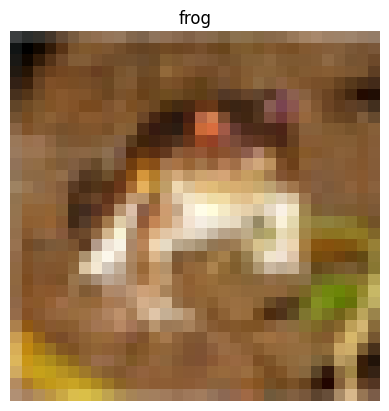

In [ ]:
plt.imshow(x_train[0])
plt.title(class_names[y_train[0][0]])
plt.axis("off")
plt.show()

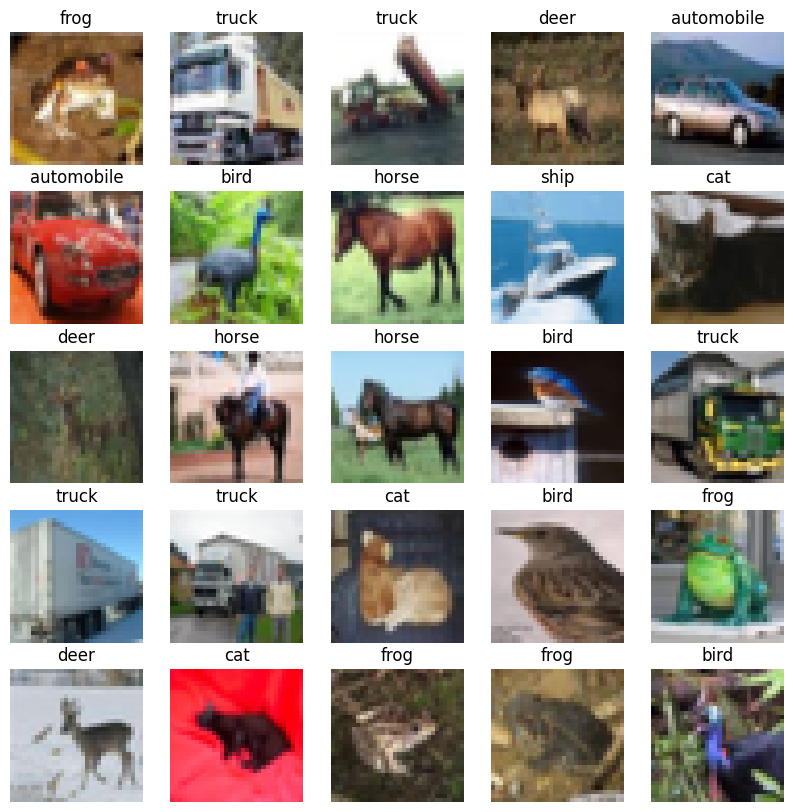

In [ ]:
plt.figure(figsize=(10, 10))

for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.show()

In [ ]:
x_train_flat = x_train.reshape(50000, 32 * 32 * 3)
x_test_flat = x_test.reshape(10000, 32 * 32 * 3)

print("x_train_flat shape:", x_train_flat.shape)
print("x_test_flat shape:", x_test_flat.shape)

x_train_flat shape: (50000, 3072)
x_test_flat shape: (10000, 3072)


In [ ]:
x_train_flat = x_train_flat / 255.0
x_test_flat = x_test_flat / 255.0

In [ ]:
y_train_flat = y_train.ravel()
y_test_flat = y_test.ravel()

print("y_train_flat shape:", y_train_flat.shape)
print("y_test_flat shape:", y_test_flat.shape)

y_train_flat shape: (50000,)
y_test_flat shape: (10000,)


In [ ]:
X_train_full = x_train_flat
y_train_full = y_train_flat

X_test_full = x_test_flat
y_test_full = y_test_flat

print("Full training set:", X_train_full.shape)
print("Full test set:", X_test_full.shape)

Full training set: (50000, 3072)
Full test set: (10000, 3072)


In [ ]:
y_train_cat = (y_train_full == 3)
y_test_cat = (y_test_full == 3)

print(y_train_cat[:20])

[False False False False False False False False False  True False False
 False False False False False  True False False]


In [ ]:
sgd_cat_clf = SGDClassifier(random_state=42)

sgd_cat_clf.fit(X_train_full, y_train_cat)

SGDClassifier(random_state=42)

In [ ]:
some_image = X_test_full[0]

prediction = sgd_cat_clf.predict([some_image])

print("Prediction:", prediction[0])
print("Actual class:", class_names[y_test_full[0]])

Prediction: False
Actual class: cat


In [ ]:
sgd_cat_scores = cross_val_score(
    sgd_cat_clf,
    X_train_full,
    y_train_cat,
    cv=3,
    scoring="accuracy"
)

print("Cross-validation accuracy scores:", sgd_cat_scores)
print("Mean accuracy:", sgd_cat_scores.mean())

Cross-validation accuracy scores: [0.89704206 0.89272215 0.84111364]
Mean accuracy: 0.8769592830872291


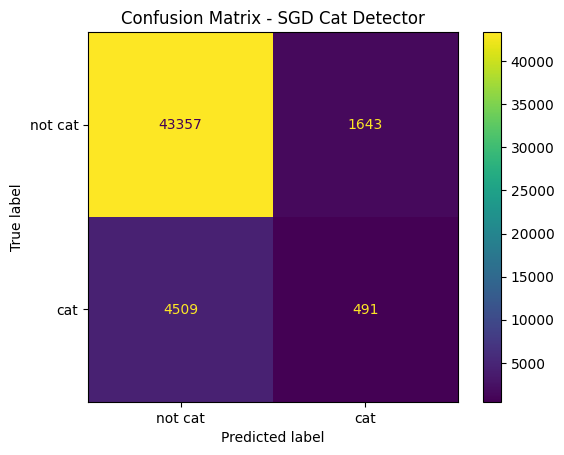

In [ ]:
y_train_cat_pred = cross_val_predict(
    sgd_cat_clf,
    X_train_full,
    y_train_cat,
    cv=3
)

cat_cm = confusion_matrix(y_train_cat, y_train_cat_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cat_cm,
    display_labels=["not cat", "cat"]
)

disp.plot()
plt.title("Confusion Matrix - SGD Cat Detector")
plt.show()

In [ ]:
precision = precision_score(y_train_cat, y_train_cat_pred)
recall = recall_score(y_train_cat, y_train_cat_pred)
f1 = f1_score(y_train_cat, y_train_cat_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1 score:", f1)

Precision: 0.23008434864104968
Recall: 0.0982
F1 score: 0.1376506868516961


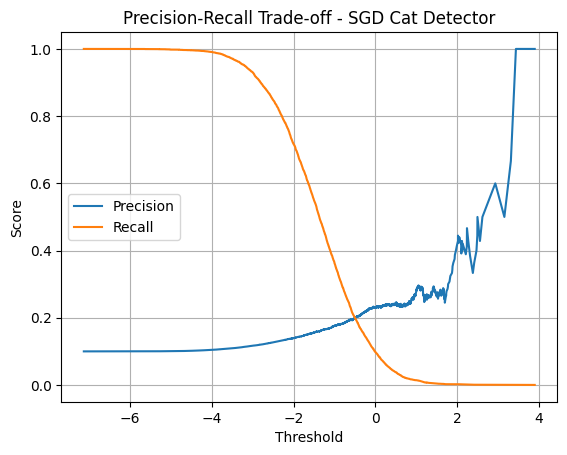

In [ ]:
y_scores = cross_val_predict(
    sgd_cat_clf,
    X_train_full,
    y_train_cat,
    cv=3,
    method="decision_function"
)

precisions, recalls, thresholds = precision_recall_curve(y_train_cat, y_scores)

plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall Trade-off - SGD Cat Detector")
plt.legend()
plt.grid()
plt.show()

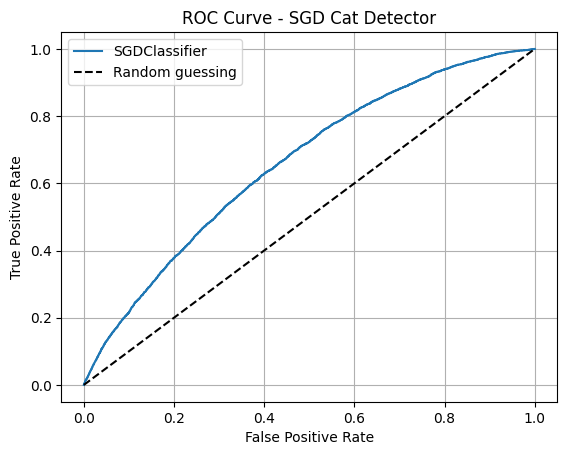

SGD ROC AUC: 0.65966592


In [ ]:
fpr, tpr, thresholds = roc_curve(y_train_cat, y_scores)

plt.plot(fpr, tpr, label="SGDClassifier")
plt.plot([0, 1], [0, 1], "k--", label="Random guessing")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SGD Cat Detector")
plt.legend()
plt.grid()
plt.show()

sgd_auc = roc_auc_score(y_train_cat, y_scores)
print("SGD ROC AUC:", sgd_auc)

In [ ]:
forest_cat_clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

forest_cat_clf.fit(X_train_full, y_train_cat)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [ ]:
y_probas_forest = cross_val_predict(
    forest_cat_clf,
    X_train_full,
    y_train_cat,
    cv=3,
    method="predict_proba"
)

y_scores_forest = y_probas_forest[:, 1]

forest_auc = roc_auc_score(y_train_cat, y_scores_forest)

print("SGD ROC AUC:", sgd_auc)
print("Random Forest ROC AUC:", forest_auc)

SGD ROC AUC: 0.65966592
Random Forest ROC AUC: 0.7335137199999999


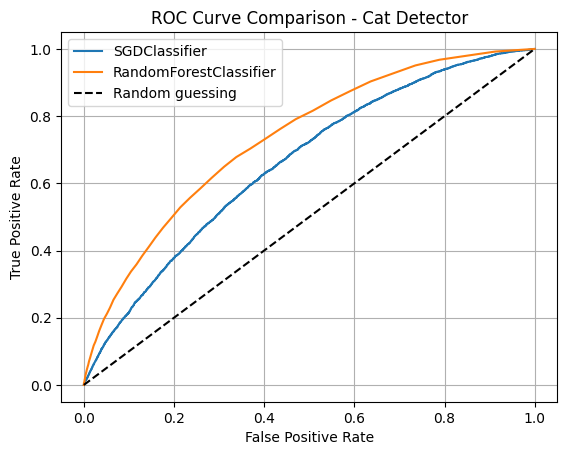

In [ ]:
fpr_forest, tpr_forest, thresholds_forest = roc_curve(y_train_cat, y_scores_forest)

plt.plot(fpr, tpr, label="SGDClassifier")
plt.plot(fpr_forest, tpr_forest, label="RandomForestClassifier")
plt.plot([0, 1], [0, 1], "k--", label="Random guessing")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison - Cat Detector")
plt.legend()
plt.grid()
plt.show()

In [ ]:
sgd_multi_clf = SGDClassifier(random_state=42)

sgd_multi_clf.fit(X_train_full, y_train_full)

SGDClassifier(random_state=42)

In [ ]:
sgd_multi_predictions = sgd_multi_clf.predict(X_test_full)

sgd_multi_accuracy = accuracy_score(y_test_full, sgd_multi_predictions)

print("SGDClassifier multiclass accuracy:", sgd_multi_accuracy)

SGDClassifier multiclass accuracy: 0.3342


In [ ]:
print(classification_report(
    y_test_full,
    sgd_multi_predictions,
    target_names=class_names,
    zero_division=0
))

              precision    recall  f1-score   support

    airplane       0.50      0.26      0.34      1000
  automobile       0.69      0.19      0.30      1000
        bird       0.23      0.42      0.30      1000
         cat       0.29      0.18      0.22      1000
        deer       0.38      0.13      0.19      1000
         dog       0.40      0.12      0.18      1000
        frog       0.32      0.54      0.40      1000
       horse       0.54      0.24      0.33      1000
        ship       0.35      0.58      0.43      1000
       truck       0.30      0.69      0.42      1000

    accuracy                           0.33     10000
   macro avg       0.40      0.33      0.31     10000
weighted avg       0.40      0.33      0.31     10000



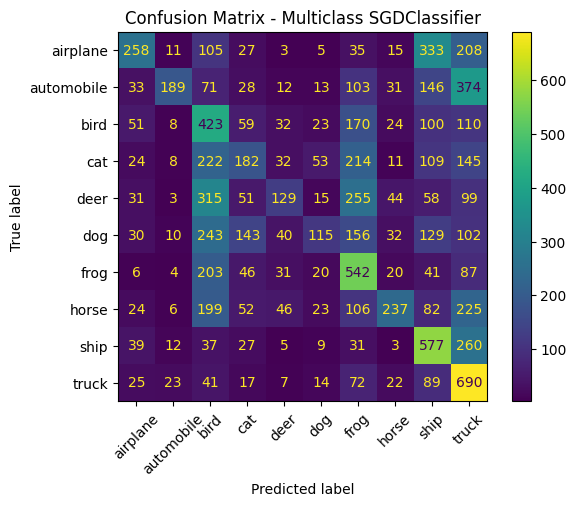

In [ ]:
sgd_multi_cm = confusion_matrix(y_test_full, sgd_multi_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=sgd_multi_cm,
    display_labels=class_names
)

disp.plot(xticks_rotation=45)
plt.title("Confusion Matrix - Multiclass SGDClassifier")
plt.show()

In [ ]:
forest_multi_clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

forest_multi_clf.fit(X_train_full, y_train_full)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [ ]:
forest_multi_predictions = forest_multi_clf.predict(X_test_full)

forest_multi_accuracy = accuracy_score(y_test_full, forest_multi_predictions)

print("RandomForestClassifier multiclass accuracy:", forest_multi_accuracy)

RandomForestClassifier multiclass accuracy: 0.4654


In [ ]:
print(classification_report(
    y_test_full,
    forest_multi_predictions,
    target_names=class_names,
    zero_division=0
))

              precision    recall  f1-score   support

    airplane       0.54      0.56      0.55      1000
  automobile       0.52      0.54      0.53      1000
        bird       0.38      0.33      0.35      1000
         cat       0.33      0.28      0.30      1000
        deer       0.39      0.38      0.39      1000
         dog       0.43      0.40      0.41      1000
        frog       0.47      0.57      0.52      1000
       horse       0.51      0.45      0.48      1000
        ship       0.58      0.61      0.59      1000
       truck       0.47      0.52      0.50      1000

    accuracy                           0.47     10000
   macro avg       0.46      0.47      0.46     10000
weighted avg       0.46      0.47      0.46     10000



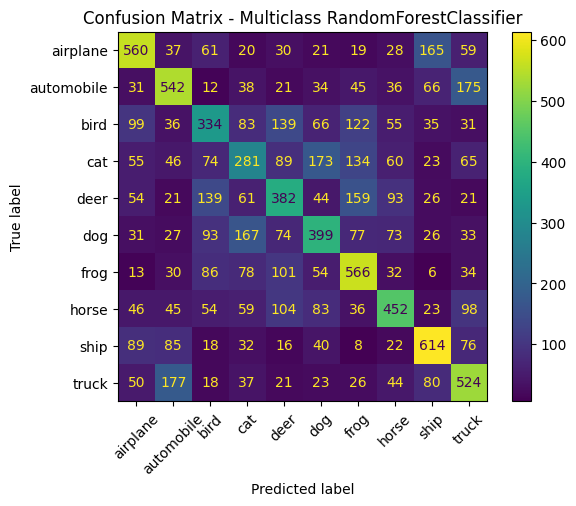

In [ ]:
forest_multi_cm = confusion_matrix(y_test_full, forest_multi_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=forest_multi_cm,
    display_labels=class_names
)

disp.plot(xticks_rotation=45)
plt.title("Confusion Matrix - Multiclass RandomForestClassifier")
plt.show()

In [ ]:
print("Binary classification ROC AUC:")
print("SGD Cat Detector:", sgd_auc)
print("Random Forest Cat Detector:", forest_auc)

print()

print("Multiclass classification accuracy:")
print("SGDClassifier:", sgd_multi_accuracy)
print("RandomForestClassifier:", forest_multi_accuracy)

Binary classification ROC AUC:
SGD Cat Detector: 0.65966592
Random Forest Cat Detector: 0.7335137199999999

Multiclass classification accuracy:
SGDClassifier: 0.3342
RandomForestClassifier: 0.4654
